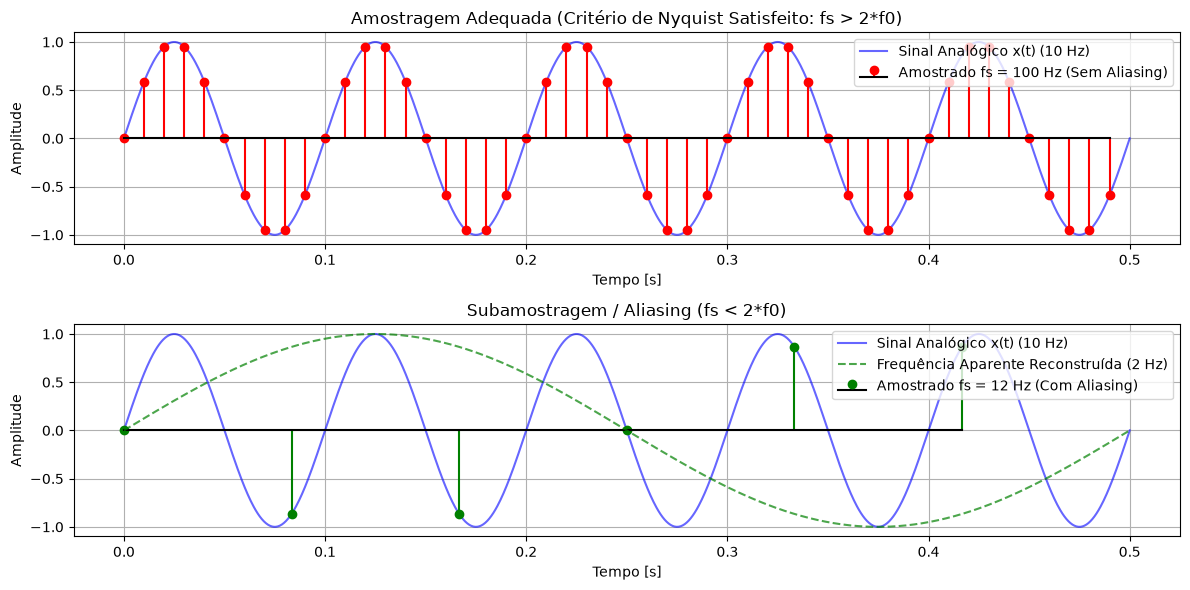

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definindo o sinal contínuo (alta densidade de pontos)
f0 = 10  # Frequência do sinal original (10 Hz)
t_cont = np.linspace(0, 0.5, 1000)
x_cont = np.sin(2 * np.pi * f0 * t_cont)

# 2. Amostragem sem Aliasing (fs1 = 100 Hz > 2*f0)
fs1 = 100
Ts1 = 1 / fs1
n1 = np.arange(0, 0.5, Ts1)
x_amostrado1 = np.sin(2 * np.pi * f0 * n1)

# 3. Amostragem com Aliasing (fs2 = 12 Hz < 2*f0)
fs2 = 12
Ts2 = 1 / fs2
n2 = np.arange(0, 0.5, Ts2)
x_amostrado2 = np.sin(2 * np.pi * f0 * n2)

# 4. Plotagem dos gráficos
plt.figure(figsize=(12, 6))

# Subplot 1: Amostragem Correta (fs = 100 Hz)
plt.subplot(2, 1, 1)
plt.plot(t_cont, x_cont, "b-", label="Sinal Analógico x(t) (10 Hz)", alpha=0.6)
plt.stem(
    n1,
    x_amostrado1,
    linefmt="r-",
    markerfmt="ro",
    basefmt="k-",
    label=f"Amostrado fs = {fs1} Hz (Sem Aliasing)",
)
plt.title("Amostragem Adequada (Critério de Nyquist Satisfeito: fs > 2*f0)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

# Subplot 2: Subamostragem com Aliasing (fs = 12 Hz)
plt.subplot(2, 1, 2)
plt.plot(t_cont, x_cont, "b-", label="Sinal Analógico x(t) (10 Hz)", alpha=0.6)
plt.stem(
    n2,
    x_amostrado2,
    linefmt="g-",
    markerfmt="go",
    basefmt="k-",
    label=f"Amostrado fs = {fs2} Hz (Com Aliasing)",
)
# Reconstrução aparente (2 Hz)
t_aliased = np.linspace(0, 0.5, 1000)
x_aliased = np.sin(2 * np.pi * 2 * t_aliased)
plt.plot(
    t_aliased,
    x_aliased,
    "g--",
    label="Frequência Aparente Reconstruída (2 Hz)",
    alpha=0.7,
)

plt.title("Subamostragem / Aliasing (fs < 2*f0)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()